In [1]:
!pip list

Package                 Version
----------------------- -----------
asttokens               3.0.1
comm                    0.2.3
contourpy               1.3.3
cuda-bindings           13.3.1
cuda-pathfinder         1.5.5
cuda-toolkit            13.0.2
cycler                  0.12.1
debugpy                 1.8.21
decorator               5.3.1
easyocr                 1.7.2
et_xmlfile              2.0.0
executing               2.2.1
filelock                3.29.4
fonttools               4.63.0
fsspec                  2026.6.0
ImageIO                 2.37.3
ipykernel               7.3.0
ipython                 9.14.1
ipython_pygments_lexers 1.1.1
jedi                    0.20.0
Jinja2                  3.1.6
jupyter_client          8.9.1
jupyter_core            5.9.1
kiwisolver              1.5.0
lazy-loader             0.5
MarkupSafe              3.0.3
matplotlib              3.11.0
matplotlib-inline       0.2.2
mpmath                  1.3.0
nest-asyncio2           1.7.2
networkx             

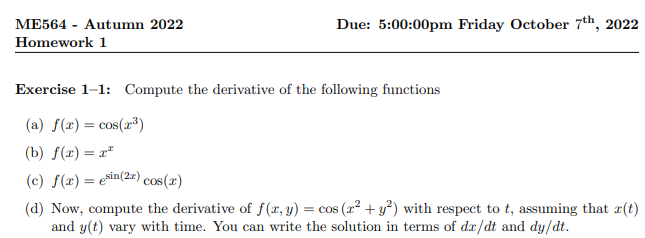

In [44]:
import sympy as smp
from IPython.display import display, Math

In [24]:
x=smp.symbols('x') #definizione delle variabili
t=smp.symbols('t')

In [62]:
#a)
f_x=smp.cos(x**3)
df_x=smp.diff(f_x,x)

display(Math(r"f_a(x) = " + smp.latex(f_x)))
display(Math(r"\frac{f_a(x)}{dx} = " + smp.latex(df_x)))
#metodo alternativo prettyprint
#smp.pprint(f_x)
#smp.pprint(df_x)
#b)
fb=(x**x)
display('Funzione b', fb)
dfb=smp.diff(fb,x)
display('Derivata di Fb',dfb)

#c)
fc=smp.exp(smp.sin(2*x))*smp.cos(x)
display(Math(r"f_c(x) = " + smp.latex(fc)))
dfc=smp.diff(fc,x)
display(Math(r"\frac{df_c(x)}{dx} = " + smp.latex(dfc)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

'Funzione b'

x**x

'Derivata di Fb'

x**x*(log(x) + 1)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [71]:
#d) Chain rule Multivariable state
x=smp.Function('x')(t)
y=smp.Function('y')(t)
#definisci x e y in fuznione di t e dopo applichi come nested functions
f=smp.cos(x**2 +y**2)
df=smp.diff(f,t)

display(Math(r"df/dt = " + smp.latex(df)))

<IPython.core.display.Math object>

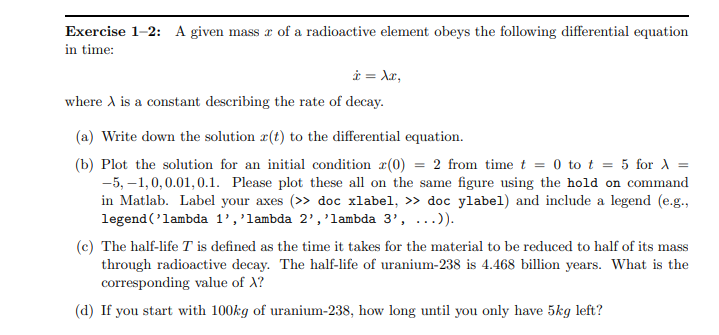

In [82]:
x_0 = smp.Symbol('x_0', constant=True)
lam = smp.Symbol('lambda')
x= smp.exp(lam * t) * x_0
display(Math(r'x(t) ='+ smp.latex(x)))


<IPython.core.display.Math object>

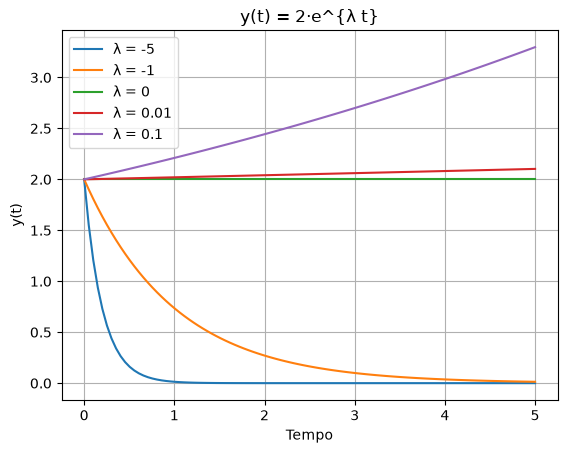

In [87]:
#Plot solution b
import numpy as np
import matplotlib.pyplot as plt

time = np.linspace(0, 5, 100)
# l = lambda, try plot for different constants
lambda_ = [-5,-1,0,0.01,0.1]

for l in lambda_:
    y=(np.exp(l*time))*2
    plt.plot(time, y, label=f'λ = {l}')

plt.xlabel('Tempo')
plt.ylabel('y(t)')
plt.title('y(t) = 2·e^{λ t}')
plt.legend()
plt.grid(True)
plt.show()


In [93]:
#calculate lambda uranium
l_uranium238=np.log(1/2)/(4*10**9)
print("lambda Uranium 238",l_uranium238)
#calculate time from lambda after t such mass goes from 100 to 5
time_238=(np.log(5/100))/l_uranium238
print("Time 100 to 5kg", time_238)

lambda Uranium 238 -1.7328679513998633e-10
Time 100 to 5kg 17287712379.54945


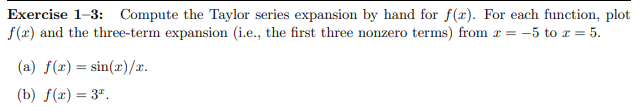

<IPython.core.display.Math object>

'Polinomio di Taylor: '

-x**6/5040 + x**4/120 - x**2/6 + 1

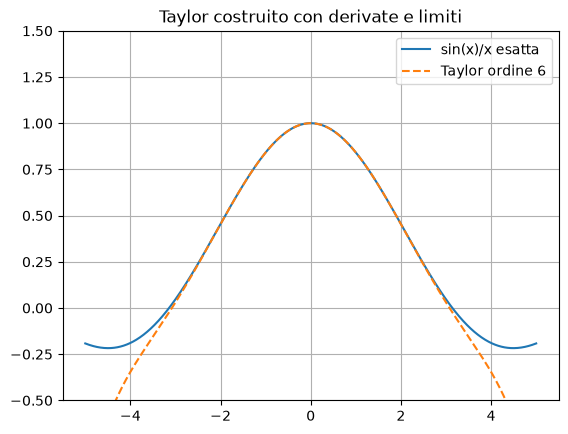

In [116]:
#write analytical Taylor series of these functions
x=smp.symbols('x')
f_x=smp.sin(x)/x
df_x=smp.diff(f_x,x)
ddf_x=smp.diff(df_x,x)
dddf_x=smp.diff(ddf_x,x)
#use sympy to find derivatives
display(Math(smp.latex(df_x) + r' ; '+ smp.latex(ddf_x) + r' ; ' + smp.latex(dddf_x)))

x_analitica=np.linspace(-5,5,1000)
y=np.sin(x_analitica)/x_analitica

##check
##Sviluppo di Taylor fino al termine x^6 (ordine 6)
taylor_ordine6 = smp.series(f_x, x, 0, 7).removeO() ##.removeO()  # removeO toglie l'O(x^7) O grande

display("Polinomio di Taylor: ", taylor_ordine6)
# TRASFORMAZIONE MAGICA: da simbolico a funzione numpy
taylor_func = smp.lambdify(x, taylor_ordine6, 'numpy')

#print(f_x,df_x,ddf_x,dddf_x)
## ok ignore this function is not 
## easier way Ty(sinx)=x-x^3+x^5.... divide by x, done. hate my life

plt.figure()
plt.plot(x_analitica, y, label='sin(x)/x esatta')
plt.plot(x_analitica, taylor_func(x_analitica), '--', label=f'Taylor ordine 6')
plt.legend()
plt.grid(True)
plt.ylim(-0.5, 1.5)
plt.title("Taylor costruito con derivate e limiti")
plt.show()

'Funzione b'

3**x

'Derivata di Fb'

3**x*log(3)

'Derivata di dFb'

3**x*log(3)**2

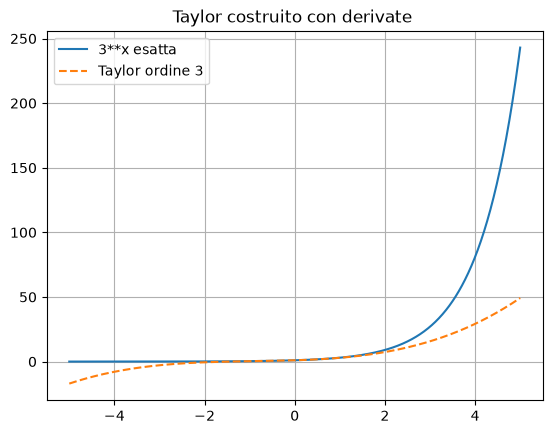

In [124]:
##f(x)=3**x
from math import factorial as fct

##i'm lazy as fuck i did the proof and now i'm not in the moooooooooodddddd

fb=(3**x)
display('Funzione b', fb)
dfb=smp.diff(fb,x)
display('Derivata di Fb',dfb)
ddfb=smp.diff(dfb,x)
display('Derivata di dFb',ddfb)
#........... f(0) +f'(0)*x + f''(0)*x^2 / 2 +.......
Ty_3 = 1/(fct(0)) + (x_analitica)*(np.log(3)/fct(1)) + (x_analitica**2)*(np.log(3)**2)/fct(2) + (x_analitica**3)*(np.log(3)**3)/fct(3) # + O(4)
#fb=smp.lambdify(x, fb, 'numpy') ## did't work, did last time, not in the mood to fix it
fb=3**x_analitica
plt.figure()
plt.plot(x_analitica, fb, label='3**x esatta')
plt.plot(x_analitica, Ty_3, '--', label=f'Taylor ordine 3')
plt.legend()
plt.grid(True)

plt.title("Taylor costruito con derivate ")
plt.show()

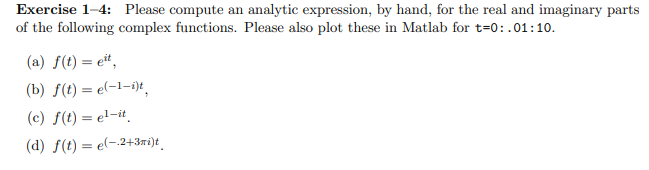

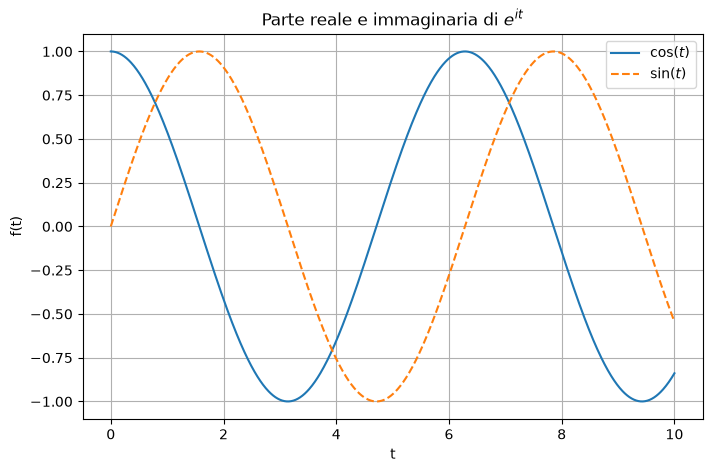

In [125]:
##Remember e is special every elevate will be i the series like e^At = series with A + A^2 +A^3 ....
## He wants e division with euler in 2 different analyticals shits
#e**it=cost+isint
t = np.arange(0, 10.01, 0.01)    # da 0 a 10 con passo 0.01

parte_reale = np.cos(t)           # Re(e^{it})
parte_imm   = np.sin(t)           # Im(e^{it})

plt.figure(figsize=(8,5))
plt.plot(t, parte_reale, label=r'$\cos(t)$')      # parte reale
plt.plot(t, parte_imm, '--', label=r'$\sin(t)$')   # parte immaginaria, tratteggiata

plt.xlabel('t')
plt.ylabel('f(t)')
plt.title(r'Parte reale e immaginaria di $e^{it}$')
plt.legend()
plt.grid(True)
plt.show()

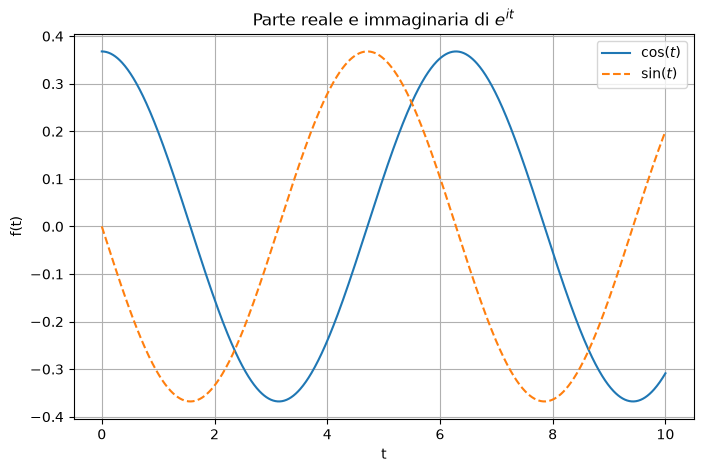

In [126]:
t = np.arange(0, 10.01, 0.01)    # da 0 a 10 con passo 0.01

parte_reale = np.cos(t)/np.exp(1)           # Re(e^{it})
parte_imm   = -np.sin(t)/np.exp(1)           # Im(e^{it})

plt.figure(figsize=(8,5))
plt.plot(t, parte_reale, label=r'$\cos(t)$')      # parte reale
plt.plot(t, parte_imm, '--', label=r'$\sin(t)$')   # parte immaginaria, tratteggiata

plt.xlabel('t')
plt.ylabel('f(t)')
plt.title(r'Parte reale e immaginaria di $e^{it}$')
plt.legend()
plt.grid(True)
plt.show()

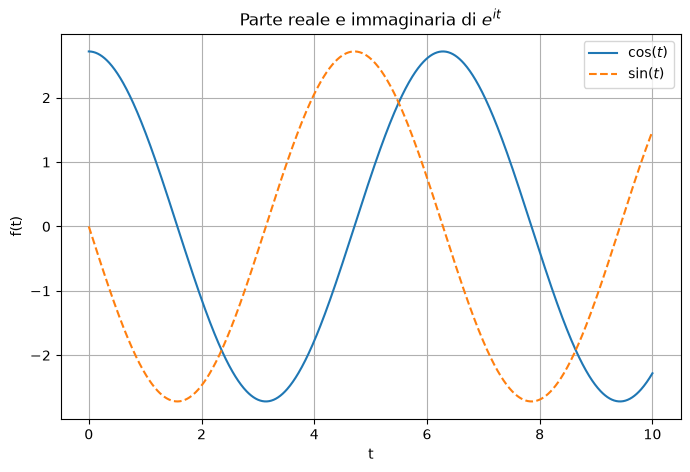

In [127]:
t = np.arange(0, 10.01, 0.01)    # da 0 a 10 con passo 0.01

parte_reale = np.exp(1)*np.cos(t)           # Re(e^{it})
parte_imm   = np.exp(1)*-np.sin(t)           # Im(e^{it})

plt.figure(figsize=(8,5))
plt.plot(t, parte_reale, label=r'$\cos(t)$')      # parte reale
plt.plot(t, parte_imm, '--', label=r'$\sin(t)$')   # parte immaginaria, tratteggiata

plt.xlabel('t')
plt.ylabel('f(t)')
plt.title(r'Parte reale e immaginaria di $e^{it}$')
plt.legend()
plt.grid(True)
plt.show()

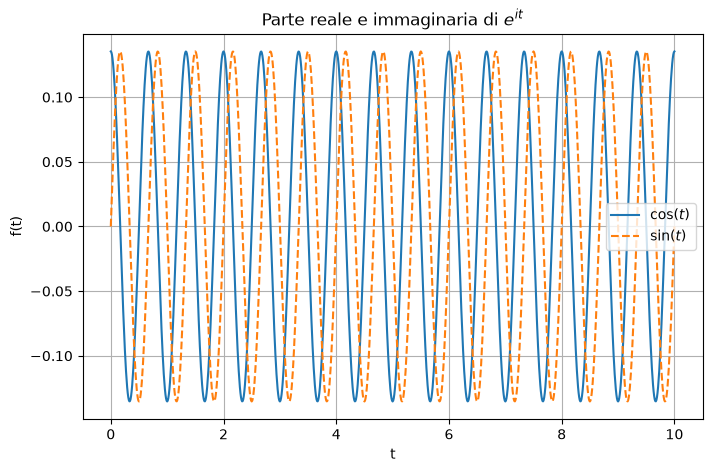

In [128]:
##Remember e is special every elevate will be i the series like e^At = series with A + A^2 +A^3 ....
## He wants e division with euler in 2 different analyticals shits
#e**it=cost+isint
t = np.arange(0, 10.01, 0.01)    # da 0 a 10 con passo 0.01

parte_reale = np.exp(-2)*np.cos(3*np.pi*t)           # Re(e^{it})
parte_imm   = np.exp(-2)*np.sin(3*np.pi*t)           # Im(e^{it})

plt.figure(figsize=(8,5))
plt.plot(t, parte_reale, label=r'$\cos(t)$')      # parte reale
plt.plot(t, parte_imm, '--', label=r'$\sin(t)$')   # parte immaginaria, tratteggiata

plt.xlabel('t')
plt.ylabel('f(t)')
plt.title(r'Parte reale e immaginaria di $e^{it}$')
plt.legend()
plt.grid(True)
plt.show()